## Применение регрессионного анализа 

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

In [35]:
df = pd.read_csv('..\data\states.csv')
df.head()

,state,metro_res,white,hs_grad,poverty,female_house
0,Alabama,55.4,71.3,79.9,14.6,14.2
1,Alaska,65.6,70.8,90.6,8.3,10.8
2,Arizona,88.2,87.7,83.8,13.3,11.1
3,Arkansas,52.5,81.0,80.9,18.0,12.1
4,California,94.4,77.5,81.1,12.8,12.6


Есть данные по штатам с различными значениями:
* metro_res - процент населения штата, живущий в столичной области  
* white - процент белокожего населения штата  
* hs_grad - процент людей, имеющих среднее образование  
* poverty - процент людей, проживающих в бедности  
* female-house - процент семей, где женщина является домохозяйкой  


### Задача 1. 
#### Исследуем взаимосвязь бедности и уровня образования при помощи линейной регрессии с одним предиктором
(бедность - зависимая переменная, уровень образования - независимая переменная (предиктор))

In [36]:
df[['hs_grad', 'poverty']].describe()

,hs_grad,poverty
count,51.000000,51.000000
mean,86.011765,11.349020
std,3.725998,3.099185
min,77.200000,5.600000
25%,83.300000,9.250000
50%,86.900000,10.600000
75%,88.700000,13.400000
max,92.100000,18.000000


**1) Построим scatter-plot (диаграмму рассеивания), чтобы получить первое впечатление о характере взаимосвязи двух данных переменных**

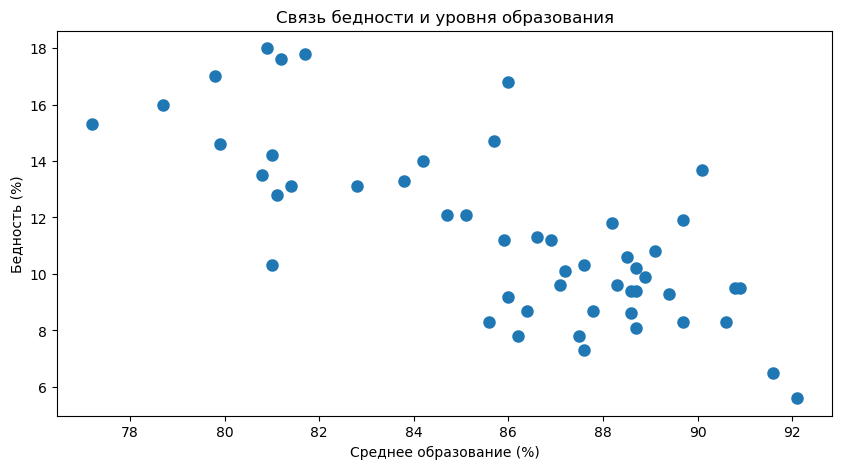

In [37]:
x = df['hs_grad']
y = df['poverty']
plt.figure(figsize=(10,5))
plt.scatter(x, y, linewidth = 3)
plt.title('Связь бедности и уровня образования', fontsize=12)
plt.xlabel("Среднее образование (%)")
plt.ylabel("Бедность (%)")
plt.show()

Заметим, что за некоторыми исключениями взаимосвязь наших ЗП и НП является линейной  
При этом взаимосвязь явно отрицательна  
Убедимся в этом, рассчитав **коэффициент корреляции:**

In [38]:
from scipy.stats import pearsonr
pearsonr_result = pearsonr(x, y)
correlation_coefficient = pearsonr_result.correlation
f'Коэффициент корреляции = {round(correlation_coefficient, 2)}'

'Коэффициент корреляции = -0.75'

In [39]:
''' Создадим таблицу с основными описательными статистиками для наших переменных '''

descriptive_statistics = pd.DataFrame({'hs_grad': x, 'poverty': y}).agg(['count', 'mean', 'std', 'min', 'max']).T
descriptive_statistics.title = 'Descriptive statistics'
descriptive_statistics

,count,mean,std,min,max
hs_grad,51.0,86.011765,3.725998,77.2,92.1
poverty,51.0,11.349020,3.099185,5.6,18.0


**Дополнение:**  
С помощью jointplot из библиотеки seaborn можно получить график, демонстрирующий взаимосвязь между двумя переменными,  
который состоит из диаграммы распределения, гистограммы, графика регрессии 

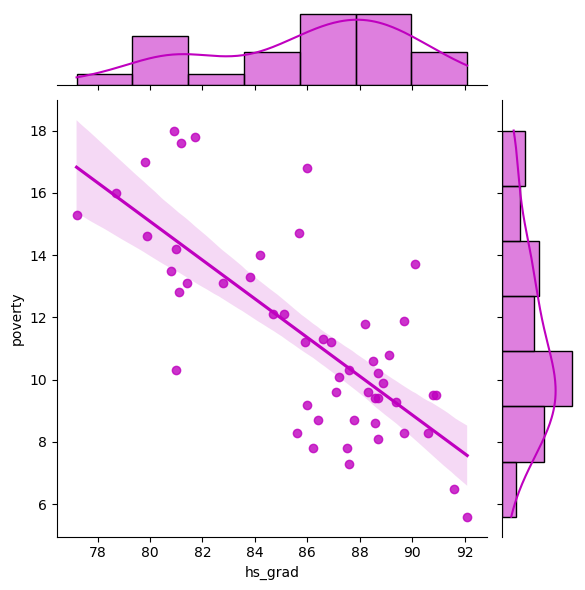

In [40]:
import seaborn as sns
sns.jointplot(x='hs_grad', y='poverty', data=df, kind='reg', color='m')

**2) Построим некоторую регрессионную модель, которая максимально удачным образом объясняет взаимосвязь двух данных переменных**  
Мы уже выяснили, что в нашем случае это будет уравнение регрессионной прямой $\hat y = b_0 + b_1 * x$   
Для того, чтобы это уравнение построить нам нужно рассчитать коэффициенты $b_0$ (intercept) и $b_1$ (slope)

In [41]:
linregress(x, y)

LinregressResult(slope=-0.6212167177940106, intercept=64.78096577010209, rvalue=-0.7468582531582505, pvalue=3.10882981031841e-10, stderr=0.0790164710017928, intercept_stderr=6.802595178281202)

In [42]:
# сохраним значения в переменных
slope, intercept, r, p_value, std_err = linregress(x, y)
intercept_stderr = linregress(x, y).intercept_stderr

**Немного о функции numpy.linspace():**    
    
Синтаксис:    
$numpy.linspace(start, stop, num, endpoint)$    
    
В этом синтаксисе:    
  
* start — начало последовательности     
* stop — конец последовательности  
* num — количество данных в выборке  
(значение по умолчанию — 50)  
* endpoint — определение конца выборки  
(если True (по умолчанию), то выборка заканчивается на последнем значении, если False — последнее значение в выборку не включается)



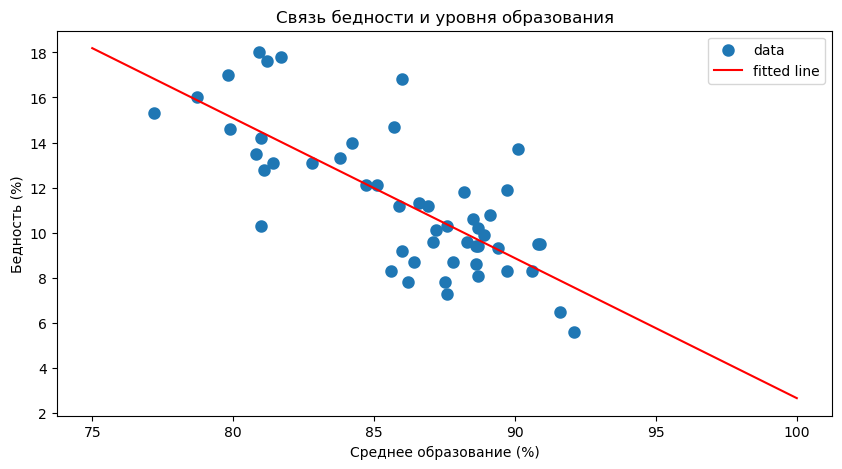

In [43]:
'''Построим модель'''
x = np.linspace(75, 100)
reg = lambda x: intercept + slope*x
plt.figure(figsize=(10,5))
plt.scatter(x='hs_grad', y='poverty', data=df, label='data', linewidth = 3) # расставляем точки
plt.xlabel('Среднее образование (%)')
plt.ylabel('Бедность (%)')
plt.title('Связь бедности и уровня образования')
plt.plot(x, reg(x), color='r', label='fitted line') # строим линию регрессии
plt.legend()
plt.show()

In [44]:
linregress_results = {'Parameter': ['intercept', 'slope'],
    'Estimate': [intercept, slope],
    'Std Error': [intercept_stderr, std_err],
}

linregress_results_df = pd.DataFrame(linregress_results).round(4)
linregress_results_df

,Parameter,Estimate,Std Error
0,intercept,64.7810,6.8026
1,slope,-0.6212,0.0790


**3) Сформулируем статистические гипотезы**   
Попробуем ответить на вопрос: отличается ли коэффициент $b_1$ от нуля?  

* Нулевая гипотеза (на языке регрессионного анализа):  
$H_0: b_1 = 0$    
(это нулевая гипотеза, т.к. если бы в ГС не было никакой взаимосвязи, то линия регрессии была бы параллельная Ох и $b_1=0$)   

* Альтернативная гипотеза:  
$H_1: b_1 \neq 0$,  
т.е. имеется некоторый наклон линии регрессии, говорящий о наличии некоторой взаимосвязи   
(гипотезу о взаимосвязи также позволяет проверить регрессионный анализ) 
 


**4) Проверим гипотезы с помощью t-критерия Стьюдента**  

In [45]:
# Рассчитываем t-value по формуле для intercept и slope
tvalue_intercept = intercept/intercept_stderr
tvalue_slope = slope/std_err

# Рассчитанное значение p-value для intercept и slope мы получили при выводе linregress(x, y)
# Добавим полученные данные в таблицу

linregress_results = {'Parameter': ['(intercept)', 'hs_grad'],
    'Estimate': [intercept, slope],
    'Std Error': [intercept_stderr, std_err],
    't-value': [tvalue_intercept, tvalue_slope],
    'Pr(>|t|)': [p_value, p_value]
}

linregress_results_df = pd.DataFrame(linregress_results).round(4)
linregress_results_df

,Parameter,Estimate,Std Error,t-value,Pr(>|t|)
0,(intercept),64.7810,6.8026,9.5230,0.0
1,hs_grad,-0.6212,0.0790,-7.8619,0.0


Для slope (b1): p-value < 0.05, поэтому $H_0$ можно отклонить (обнаружили статистич. значимую взаимосвязь двух переменных)  
  
Для intercept (b0): p-value < 0.05, т.е. если предположить существование такого штата, где процент людей со средним образованием равен 0 (x = 0),   
то мы ожидаем, что в таком штате будет примерно 64.78% - процент людей, проживающих за чертой бедности (у = 64.78)


**5) Интерпретация значения коэффициента $b_1$**  

$b_1 = -0.62$ (slope) => взаимосвязь отрицательная  
(т.е. с каждым процентом увеличения количества людей, имеющих среднее образование (hs_grad),    
мы ожидаем, что количество людей, проживающих в бедности (poverty) будет уменьшаться на 0.62%)  

Таким образом, в случае применения регрессионного анализа в подобного рода задачах коэффициенты, стоящие перед независимыми переменными, имеют определенный **смысл**:  _это то, как будет изменяться значение зависимой переменной (y) с единичным изменением независимой переменной (x)_

**6) Рассчитаем коэффициент детерминации**  
С помощью коэф-та детерминации сможем понять, какой процент дисперсии объясняется нашей моделью  
Тем самым выясним, на сколько хорошо наша модель объясняет поведение зависимой переменной

In [46]:
f'Multiple R-squared = {r ** 2:.4f}' # возвели коэф-т корреляции в квадрат, т.к. в одномерном регресс. анализе равенство сохраняется

'Multiple R-squared = 0.5578'

Таким образом, практически 56% изменчивости нашей зависимой переменной (у) объясняется нашей регрессионной моделью  
На самом деле это не так уж и много, поскольку получается, что практически половина изменчивости обуславливается не включенными в модель факторами

Заметим, что в основной формуле коэффициента детерминации в числителе и знаменателе находятся сумма квадратов остатков и общая изменчивость соответственно 
Это указывает на распределение Фишера со степенями свободы 1 (число групп-1) и 49 (количество наблюдений-число групп)

**7) Рассчитаем F-статистику с помощью дисп. анализа и p-value для нее**  
Для того, чтобы проверить гипотезу о том, что наша модель в целом позволяет объяснить поведение зависимой переменной  
(как интерпретировать p-value для всей модели в целом - станет ясно после темы "Множественная регрессия",  
где сразу несколько предикторов могут быть включены в модель)

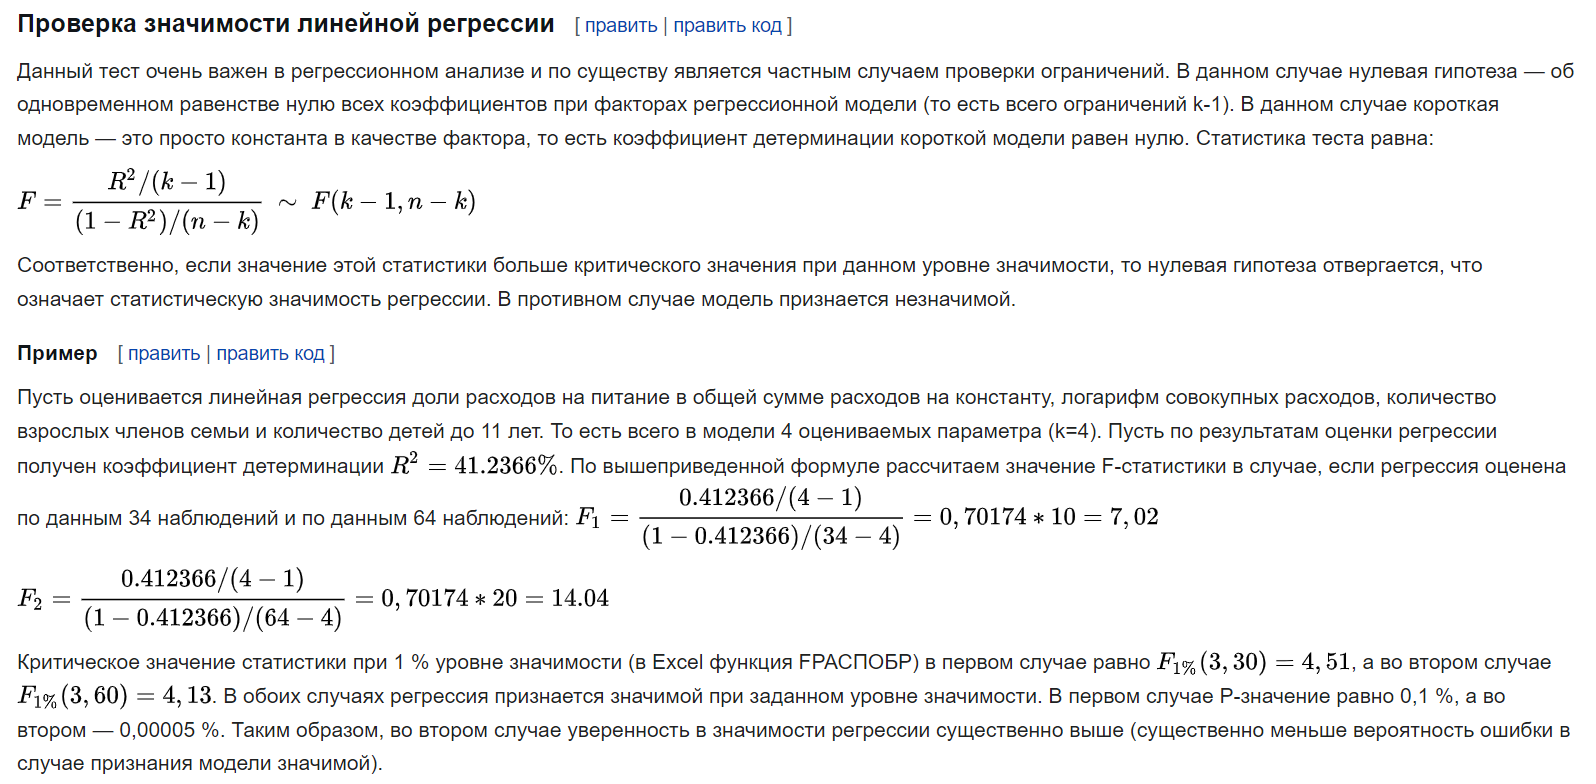

In [53]:
# проверка значимости линейной регрессии из Википедии
from IPython.display import Image
Image('../img/formula_fstatistic.png') 

# в нашем случае k = 2, т.к. в модели 2 оцениваемых параметра (hs_grad, poverty)
# тогда k-1 = 1, n-k = n-2 = degrees_of_freedom
# получим формулу: F = r**2/(1-r**2)*(degrees_of_freedom)

Получается, для проверки значимости линейной регрессии, нужно проверить гипотезу о том, что $R^2 = 0$

In [54]:
import scipy.stats as stats
k = 2 # кол-во сравниваемых групп
df_for_ssw = df['hs_grad'].count() - 2 # степени свобод для внутригрупповой суммы квадратов
df_for_ssb =  k - 1 # степени свобод для междугрупповой суммы квадратов
F = (r**2/df_for_ssb)/((1-r**2)/df_for_ssw)
p_val = stats.f.sf(F, 1, df_for_ssw)

f'F-statistic (1, {df_for_ssw}) = {F:.2f}, p-value = {p_val:.2f} < 0.01'

'F-statistic (1, 49) = 61.81, p-value = 0.00 < 0.01'

**8) Подведение итогов**  
Мы хотели выяснить, как взаимосвязанны две переменные (уровень бедности и уровень образования) между собой  
Для этого применили регрессионный анализ с одной независимой переменной
И посмотрели, на сколько эта взаимосвязь значима, взаимосвязь оказалась отрицательной  
Построили некоторую линейную модель, которая хорошо описывает взаимосвязь этих двух переменных  
Выяснили, какой процент дисперсии одной переменной обуславливается взаимосвязью с другой переменной  
Посмотрели, на сколько мы будем ожидать изменения уровня бедности с единичным изменением уровня образования (интерпретация b1)

### Задача 2.
#### Проверим выполнение требований к применению линейной регрессии с одним предиктором

**1) Линейная взаимосвязь х и у**  
Была проверена в Задаче 1

**2) Нормальное распределение остатков**

**3) Гомоскедастичность**

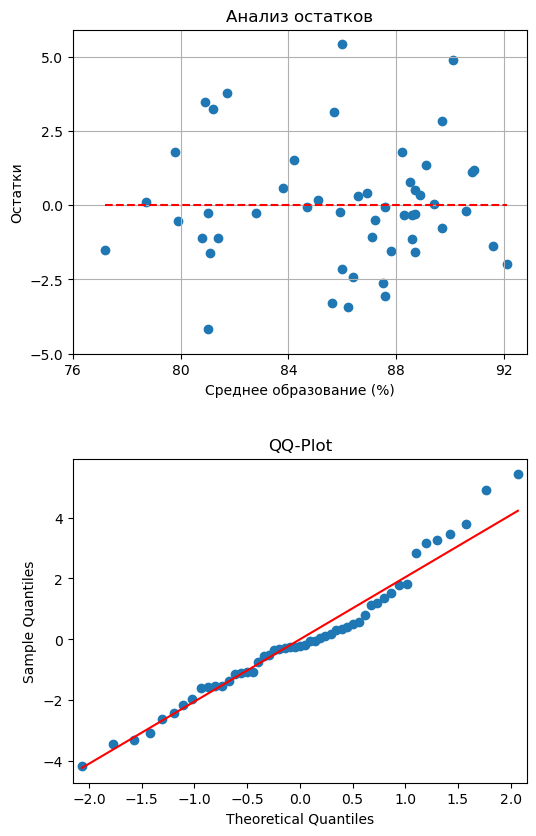

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
import statsmodels.api as sma

# получаем данные и вычисляем коэффициенты регрессионной модели
data=pd.read_csv('..\data\states.csv', sep=',')
intercept, slope = sm.ols(formula="poverty ~ hs_grad", data=data).fit().params
X = data['hs_grad']
Y = data['poverty']

# вычисляем остатки - на сколько Y далека от теоретической модели
residuals = Y - intercept - slope*X
x1=np.linspace(min(X),max(X),len(X))

# создаем графики
fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6, 9))
# scatter plot
ax1.scatter(X,residuals)
ax1.plot(x1,[0]*len(x1),'--r')
# Q-Q plot
sma.qqplot(residuals, line='s', ax = ax2)

ax1.grid()
ax1.set_title('Анализ остатков')
ax1.set_xlabel('Среднее образование (%)')
ax1.set_ylabel('Остатки')
ax1.set_xticks(np.arange(76,93, step=4))
ax1.set_yticks(np.arange(-5,6, step=2.5))

ax2.set_title('QQ-Plot')

fig.tight_layout(pad=3.0)
plt.show()

**На графике 1**    
Можем посмотреть, как остатки распределились вокруг регрессионной прямой:     
Какая-то часть остатков положительна, какая-то отрицательна,  
но в целом изменчивость остатков сохраняется примерно одинаковой на всём протяжении значений независимой переменной    
А, значит, **требование гомоскедастичности выполнено**  

**На графике 2**    
Построено распределение остатков при помощи графика qq-plot    
Подавляющая часть всех наблюдений лежит на прямой линии, следовательно, **распределение нормальное**    
Но всё-таки есть несколько значений, которые принимают экстремально высокие значения    
(действительно, штаты, которые сильно отклоняются в положительную сторону от регрессионной прямой можно было увидеть еще на этапе построения регрессионной модели)  
Эти значения ведут себя не так хорошо в соответствии с нашей моделью, но при работе с реальными данными идеальные результаты получить невозможно    
(т.е. мы не получим ситуацию, чтобы все наблюдения были абсолютно нормально распределены, а все взаимосвязи были абсолютно линейные)    
Поэтому результаты проведенного анализа позволяют сделать **вывод: применение регрессионного анализа было обоснованным**  

Т.к. остатки распределены относительно нормально и изменчивость остатков является постоянной на протяжении всех значений независимой переменной,    
то нашей модели можно доверять => можно попробовать предсказывать значения зависимой переменной, основываясь на значениях независимой переменной  


### Задача 3.
#### Предсказание значений зависимой переменной

Регрессионную прямую иногда называют **_линией тренда_**  
Основываясь на линии тренда, мы може предсказать чему будут равны значения ЗП на определенном уровне значений НП


**Пример**  
Чему бы равнялся процент людей, проживающих в бедности, в штате, где среднее образование имеет 95% населения?  

В нашей выборке такого наблюдения не было, но основываясь на линии тренда, которую предоставляет регрессионный анализ, мы можем сделать предсказание относительно такого события   
(Кстати, наша выборка соответствует ГС (такой вот редкий случай))  

Можем нанести точку (х = 95%) на регрессионную прямую (это будет самой точной оценкой, которую мы можем дать в нашем случае),  
тогда легко увидеть процент бедности (у) при данном х

Мы помним, что уравнение регрессионной прямой имеет вид: y = 64.78 - 0.62x  
Поэтому можно подставить х = 95% и получить предсказанное значение бедности (у) в этой ситуации


In [56]:
y_fit = 64.78 - 0.62 * 95
round(y_fit, 2)

5.88

Таким образом, основываясь на линии регрессии, можно предсказать те значения, которых на самом деле нет   

**Замечание:**  
Задача предсказания сопряжена с некоторыми ограничениями 

_Возможные проблемы задач с предсказаниями:_
1. В задаче выше линия тренда могла принять на каком-то этапе и отрицательные значения (это не имело бы смысла для такого показателя, как процент бедности)    
2. Поведение переменной является линейным только на некотором промежутке    
Например, рассмотрим взаимосвязь роста и возраста человека    
На промежутке 0-20 лет взаимосвязь будет линейной (чем старше, тем выше)    
Однако потом значение роста перестанет изменяться, но линия тренда бы этого не показала и ушла бы вверх
(если бы в исходной выборке были бы только люди, младше 20 лет)  

Таким образом, <u>пользуясь линейной регрессией в качестве инструмента для предсказания значений</u>, нужно убедиться в том, что  
**Регрессионная модель надежная и хорошо описывает взаимосвязь двух исследуемых переменных**, т.е. выполняются требования: 
1. Линейность взаимосвязи двух переменных   
(важно понимать, что если в нашей выборке две переменные взаимосвязанны линейно, то это не означает, что линейная взаимосвязь сохранится при продолжении линии тренда до какого-то высокого показателя по одной из переменных)  
2. Нормальное распределение остатков  
3. Постоянная изменчивость остатков (гомоскедастичность) - в случае его нарушения модель потеряет предсказательную силу


## Интерпретация результатов

**Важно помнить:** факт значимой взаимосвязи в регрессионном анализе ничего не говорит о причинно-следственной направленности  

В нашем случае мы получили значимую взаимосвязь уровня образования и уровня бедности  
С одной стороны, это может быть объяснено так: "Чем больше люди учатся, тем лучше они работают и выше их уровень благостостояния"  
С другой стороны, может быть и так: "Чем ниже благосостояние населения, тем меньше времени на учебу и уровень образованных людей по стране ниже"  
Поэтому факт взаимосвязи ничего не говорит о причинно-следственных отношениях между двумя этими переменными  

То, что одна переменная - зависимая, а другая - независимая  
То, что в рамках регрессионного анализа мы говорим фразы "влияет", "обуславливает"  
Вовсе не означает, что эту взаимосвязь можно в прямом смысле перенести на реальные данные в виде причинно-следственной взаимосвязи